In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time

In [2]:
def general(t, y, lam, delta, alpha):
  #alpha = 0 -> SIR v  delta = 0 -> Maki-Thompson
  X = y[0]
  Y = y[1]
  Z = y[2]
  dXdt = -lam * X * Y
  dYdt = lam * X * Y - delta * Y - alpha * Y * (1 - X)
  dZdt = delta * Y + alpha * Y * (1 - X)
  return np.array([dXdt, dYdt, dZdt])

In [3]:
def rk4(f, y0, t, lam, delta, alpha):
  n = len(t)
  y0 = np.array(y0)
  y = np.zeros((n, len(y0)))
  y[0] = y0
  #print(f"y0: {y0}")
  #print(f"y: {y}")

  for i in range(n-1):
    h = t[i+1] - t[i]
    #print(f"bucle entry {y[i]}")
    k1 = np.array(f(t[i], y[i], lam, delta, alpha))
    #print("bucle out")
    k2 = np.array(f(t[i] + h/2, y[i] + h*k1/2, lam, delta, alpha))
    k3 = np.array(f(t[i] + h/2, y[i] + h*k2/2, lam, delta, alpha))
    k4 = np.array(f(t[i] + h, y[i] + h*k3, lam, delta, alpha))

    y[i+1] = y[i] + (h/6) * (k1 + 2*k2 + 2*k3 + k4)

  return y

In [4]:
class general_nn(nn.Module):
  def __init__(self, typeModel):
    super().__init__()

    self.net = nn.Sequential(
               nn.Linear(1, 32),
               nn.Tanh(),
               nn.Linear(32, 32),
               nn.Tanh(),
               nn.Linear(32, 32),
               nn.Tanh(),
               nn.Linear(32, 3))

    self.lam = nn.Parameter(torch.tensor([0.5]))

    self.typeModel = typeModel
    if (self.typeModel == "SIR"):
      self.alpha = 0
      self.delta = nn.Parameter(torch.tensor([0.5]))
    elif (self.typeModel == "MT"):
      self.alpha = nn.Parameter(torch.tensor([0.5]))
      self.delta = 0

  def forward(self, t):
    return nn.Softplus()(self.net(t))

In [5]:
# Derivar
def derivar(y, t):
  return torch.autograd.grad(y, t, grad_outputs= torch.ones_like(y), create_graph= True, retain_graph= True)[0]

# Losses
def loss_ic(model, y_0):
  m_0 = model(torch.tensor([0.0]))
  y_0_t = torch.tensor(y_0)

  return torch.mean((m_0 - y_0_t)**2)

def loss_edo(model, t):
  tmp = model(t)
  x = tmp[:, 0:1]
  y = tmp[:, 1:2]
  z = tmp[:, 2:3]

  lam = model.lam
  delta = model.delta
  alpha = model.alpha

  dx_dt = derivar(x, t)
  dy_dt = derivar(y, t)
  dz_dt = derivar(z, t)

  diff_x = dx_dt + lam * x * y
  if (model.typeModel == "SIR"): # Alpha 0
    diff_y = dy_dt - lam * x * y + delta * y
    diff_z = dz_dt - delta * y
  elif (model.typeModel == "MT"): #Delta 0
    diff_y = dy_dt - lam * x * y + alpha * y * (1 - x)
    diff_z = dz_dt - alpha * y * (1 - x)

  return torch.mean(diff_x**2 + diff_y**2 + diff_z**2)

def loss_data(model, t, id_h_points, sol):
  t_h = t[id_h_points]

  model_h = model(t_h)
  sol_h = torch.tensor(sol[id_h_points])

  # Tensor's
  return torch.mean((sol_h - model_h)**2)

def loss_sum_1(model, t):
  tmp = model(t)

  x = tmp[:, 0:1] 
  y   = tmp[:, 1:2]
  z = tmp[:, 2:3]

  return torch.mean((x + y + z - 1.0)**2)

In [6]:
# Timeline
t_start = 0.0
t_end = 40.0
n_points = 2000
t_real = torch.linspace(t_start, t_end, n_points).reshape(-1, 1)

# Initial conditions
s_0, i_0, r_0 = 0.95, 0.05, 0.0
y_0 = [s_0, i_0, r_0]


# N Epocas
n_ephocs = 10000

# Learning Rate
lr = 1e-3

In [7]:
# NN Simulation
def train(hasWeights, nHelperPoints, sol_noisy, typeModel):
  model = general_nn(typeModel)  
  # Optimizer
  optimizer = optim.Adam(model.parameters(), lr)

  # Weights
  ic_weight = 10
  edo_weight = 40
  data_weight = 0.9
  sum_weight = 1


  #Helper points
  h_points = []
  id_h_points = []
  
  id_h_points = np.linspace(0, n_points - 1, nHelperPoints, dtype = int)
  h_points = t_real[id_h_points].detach().numpy()

  tColloc = torch.linspace(t_start, t_end, 50).reshape(-1, 1)
  
  tColloc.requires_grad = True
  # Training loop
  startTime = time.perf_counter()
  for epoch in range(n_ephocs):

    if (hasWeights == True):
      loss = ic_weight * loss_ic(model, y_0) + edo_weight * loss_edo(model, tColloc) + data_weight * loss_data(model, t_real, id_h_points, sol_noisy) + sum_weight * loss_sum_1(model, tColloc)
    else:
      loss = loss_ic(model, y_0) + loss_edo(model, tColloc) + loss_data(model, t_real, id_h_points, sol_noisy) + loss_sum_1(model, tColloc)  
  
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    
  endTime = time.perf_counter()
  return model, endTime - startTime, id_h_points

In [8]:
def getNoiseBase(sol):
  # Noise
  noise_base = []
  noise_base.append(np.random.uniform(0.7, 1.0, size=sol.shape[0])) # S
  noise_base.append(np.random.uniform(0.7, 1.0, size=sol.shape[0])) # I
  noise_base.append(np.random.uniform(0.7, 1.0, size=sol.shape[0])) # R
  
  noise_sign = []
  noise_sign.append(np.random.choice([-1, 1], size=sol.shape[0])) # S
  noise_sign.append(np.random.choice([-1, 1], size=sol.shape[0])) # I
  noise_sign.append(np.random.choice([-1, 1], size=sol.shape[0])) # R

  return noise_base, noise_sign

In [9]:
def getNoisySolution(solution, noiseBase, noiseSign, percentage):
  solNoisy = solution.copy()
  for k in range(3):  # S, I, R
    maxVal = np.max(solution[:, k])
    noiseScaled = noiseBase[k] * noiseSign[k] * (percentage/100.0) * maxVal
    
    solNoisy[:, k] += noiseScaled
    solNoisy[:, k]  = np.abs(solNoisy[:, k])
  solNoisy = np.clip(solNoisy, 0.0, 1.0)

  return solNoisy

# SIR

In [10]:
# Beta & gamma
lam = 1.0
delta = 0.05
alpha = 0.0

# SIR SOL
sirSol = rk4(general, y_0, t_real.detach().numpy(), lam, delta, alpha);
# Noise
noiseBase, noiseSign = getNoiseBase(sirSol)
solNoisySIR = getNoisySolution(sirSol, noiseBase, noiseSign, 10)

In [11]:
print("Start training")
SIRmodel, t_time, points = train(True, 16, solNoisySIR, "SIR")
print("End training")

Start training
End training


In [12]:
tPlot = t_real.detach().numpy()

lam: 0.9575387239456177, delta: 0.05218653753399849, alpha: 0


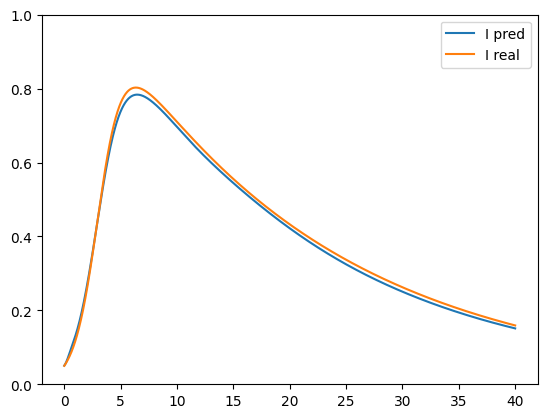

In [13]:
SIRtoPlot = SIRmodel(t_real).detach().numpy()
plt.plot(tPlot, SIRtoPlot[:, 1], label = "I pred")
plt.plot(tPlot, sirSol[:, 1], label = "I real")

plt.ylim(0.0, 1.0)
plt.title("SIR model")
plt.legend()
plt.draw()
print(f"lam: {SIRmodel.lam.item()}, delta: {SIRmodel.delta.item()}, alpha: {SIRmodel.alpha}")

# Maki-Thompson

In [14]:
# Beta & gamma
lam = 1.0
delta = 0.0
alpha = 0.05


# SIR MT
MTSol = rk4(general, y_0, t_real.detach().numpy(), lam, delta, alpha);
noiseBase, noiseSign = getNoiseBase(MTSol)
solNoisyMT = getNoisySolution(MTSol, noiseBase, noiseSign, 10)

In [15]:
print("Start training")
MTmodel, t_time, points = train(True, 16, solNoisyMT, "MT")
print("End training")

Start training
End training


In [ ]:
MTtoPlot = MTmodel(t_real).detach().numpy()
plt.plot(tPlot, MTtoPlot[:, 1], label = "Y pred")
plt.plot(tPlot, MTSol[:, 1], label = "Y real")

plt.ylim(0.0, 1.0)
plt.legend()
plt.draw()
plt.title("MT model")
print(f"lam: {MTmodel.lam.item()}, delta: {MTmodel.delta}, alpha: {MTmodel.alpha.item()}")